In [2]:
import os
import numpy as np
from dataset import load_dataset
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.linear_model import BayesianRidge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [3]:
OUTPUT_PATH= "../../../output/bayesian_ridge/"
FILE_PATH_TRAIN = "../../../data/processed/split_85_15/train_85.csv"
FILE_PATH_TEST  = "../../../data/processed/split_85_15/test_15.csv"
OUTPUT_FOR_SVM  = os.path.join(OUTPUT_PATH, "pred_margin_test_bayesian.csv")
FEATURES = ["trq_measured", "mgt", "ias", "oat", "np_ng_ratio", "pa"]
TARGET_COL = "trq_target"
MODEL="bayesian_ridge.pkl"

train_df = load_dataset(FILE_PATH_TRAIN)
test_df  = load_dataset(FILE_PATH_TEST)

# Training
X_train = train_df[FEATURES].values
y_train = train_df[TARGET_COL].values

In [6]:
model = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("reg", BayesianRidge())
])

model.fit(X_train, y_train)
joblib.dump(model, OUTPUT_PATH + MODEL)

X_test = test_df[FEATURES].values
y_test = test_df[TARGET_COL].values
trq_measured_test = test_df["trq_measured"].values

mu_test, sigma_test = model.predict(X_test, return_std=True)

df_out = test_df.copy()

df_out["trq_target_pred"] = mu_test

df_out["trq_margin_pred"] = 100 * (trq_measured_test / (mu_test + 1e-8) - 1)
df_out["trq_margin_true"] = 100 * (trq_measured_test / (y_test + 1e-8) - 1)

df_out["std_margin_pred"] = np.abs(-100 * trq_measured_test / (mu_test**2 + 1e-8)) * sigma_test



df_out.to_csv(OUTPUT_FOR_SVM, index=False)
print(f"Dataset aggiornato salvato in: {OUTPUT_FOR_SVM}")

Dataset aggiornato salvato in: ../../../output/bayesian_ridge/pred_margin_test_bayesian.csv


In [13]:
mae = mean_absolute_error(y_test, mu_test)
rmse = np.sqrt(mean_squared_error(y_test, mu_test))
r2 = r2_score(y_test, mu_test)

pdf_true = norm.pdf(y_test, mu_test, sigma_test)
pdf_max = norm.pdf(mu_test, mu_test, sigma_test)
scores = pdf_true / pdf_max
avg_true_score = np.mean(scores)

print("\n===== PERFORMANCE REGRESSIONE (TEST) =====")
print(f"MAE              : {mae:.6f}")
print(f"RMSE             : {rmse:.6f}")
print(f"R2               : {r2:.6f}")
print(f"AVG TRUE SCORE   : {avg_true_score:.6f}")



===== PERFORMANCE REGRESSIONE (TEST) =====
MAE              : 0.021049
RMSE             : 0.036485
R2               : 0.999993
AVG TRUE SCORE   : 0.828875


In [14]:
i = 100

volo_id = test_df.iloc[i]['id'] if 'id' in test_df.columns else i

true_i = y_test[i]
mu_i = mu_test[i]
sigma_i = sigma_test[i]
t_m = trq_measured_test[i]

margin_pred_i = df_out["trq_margin_pred"].iloc[i]
margin_true_i = df_out["trq_margin_true"].iloc[i]
margin_sigma_i = df_out["std_margin_pred"].iloc[i]

print(f"\n--- Analisi Volo ID: {volo_id} ---")
print(f"Coppia Misurata   : {t_m:.4f}")
print(f"Coppia Predetta   : {mu_i:.4f} (± {sigma_i:.4f})")
print(f"Margin Vero       : {margin_true_i:.4f} %")
print(f"Margin Predetto   : {margin_pred_i:.4f} %")
print(f"Incertezza (std)  : {margin_sigma_i:.4f}")


--- Analisi Volo ID: 100 ---
Coppia Misurata   : 67.8000
Coppia Predetta   : 72.1550 (± 0.0363)
Margin Vero       : -6.0470 %
Margin Predetto   : -6.0356 %
Incertezza (std)  : 0.0473


In [15]:
samples_target = np.random.normal(mu_i, sigma_i, 100000)
margin_samples = 100 * (t_m / samples_target - 1)

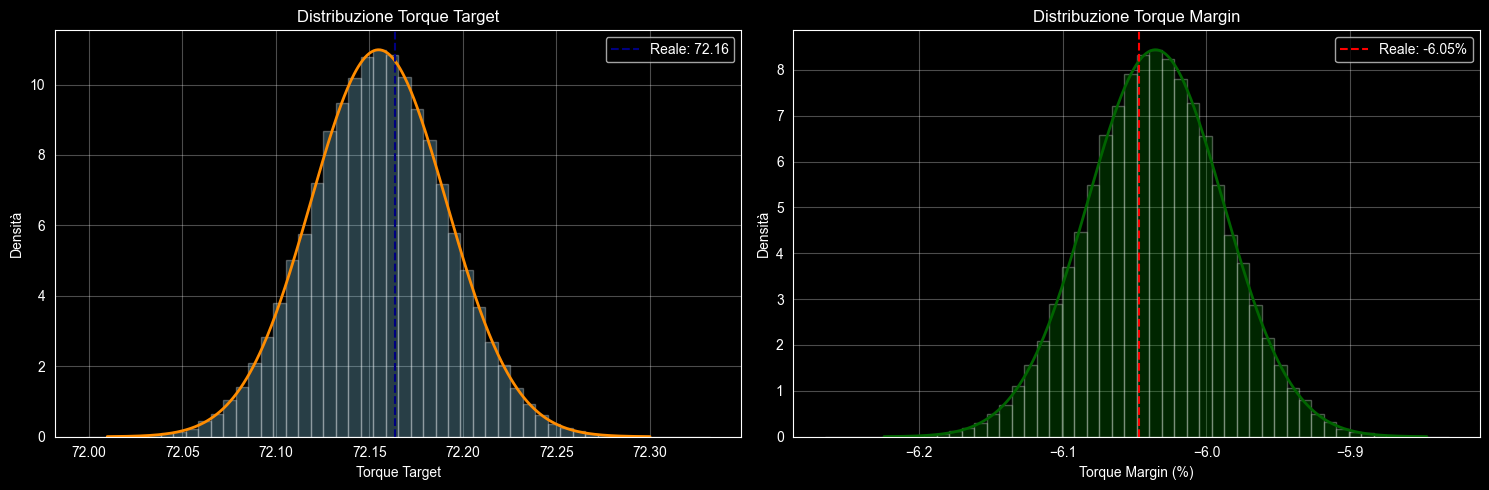

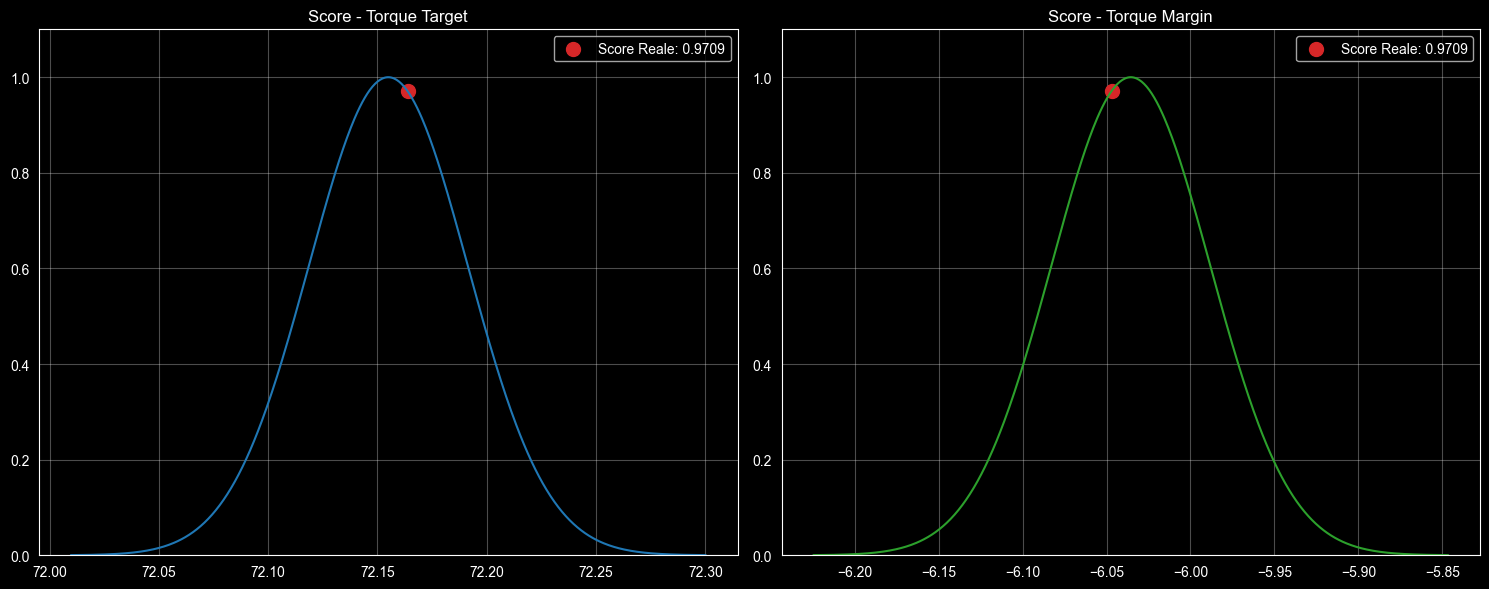

In [16]:
# PLOT DISTRIBUZIONI
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(samples_target, bins=50, density=True, alpha=0.3, color='skyblue')
x_t = np.linspace(mu_i - 4*sigma_i, mu_i + 4*sigma_i, 500)
ax1.plot(x_t, norm.pdf(x_t, mu_i, sigma_i), color='darkorange', lw=2)
ax1.axvline(true_i, color='navy', ls='--', label=f"Reale: {true_i:.2f}")
ax1.set_title("Distribuzione Torque Target")
ax1.set_xlabel("Torque Target"); ax1.set_ylabel("Densità"); ax1.legend(); ax1.grid(alpha=0.3)

ax2.hist(margin_samples, bins=50, density=True, alpha=0.3, color='green')

# Curve basata sul calcolo Metodo Delta
x_m = np.linspace(margin_pred_i - 4*margin_sigma_i, margin_pred_i + 4*margin_sigma_i, 500)
ax2.plot(x_m, norm.pdf(x_m, margin_pred_i, margin_sigma_i), color='darkgreen', lw=2)
ax2.axvline(margin_true_i, color='red', ls='--', label=f"Reale: {margin_true_i:.2f}%")
ax2.set_title("Distribuzione Torque Margin")
ax2.set_xlabel("Torque Margin (%)"); ax2.set_ylabel("Densità"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# PLOT CURVA SCORE
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(15, 6))

score_true_t = norm.pdf(true_i, mu_i, sigma_i) / norm.pdf(mu_i, mu_i, sigma_i)
ax3.plot(x_t, norm.pdf(x_t, mu_i, sigma_i) / norm.pdf(mu_i, mu_i, sigma_i), color='tab:blue')
ax3.scatter(true_i, score_true_t, s=100, color='tab:red', label=f"Score Reale: {score_true_t:.4f}")
ax3.set_title("Score - Torque Target")
ax3.set_ylim(0, 1.1); ax3.legend(); ax3.grid(alpha=0.3)

score_true_m = norm.pdf(margin_true_i, margin_pred_i, margin_sigma_i) / norm.pdf(margin_pred_i, margin_pred_i, margin_sigma_i)
ax4.plot(x_m, norm.pdf(x_m, margin_pred_i, margin_sigma_i) / norm.pdf(margin_pred_i, margin_pred_i, margin_sigma_i), color='tab:green')
ax4.scatter(margin_true_i, score_true_m, s=100, color='tab:red', label=f"Score Reale: {score_true_m:.4f}")
ax4.set_title("Score - Torque Margin")
ax4.set_ylim(0, 1.1); ax4.legend(); ax4.grid(alpha=0.3)

plt.tight_layout(); plt.show()